In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("/content/Ice_cream selling data.csv")

x_train = df["Temperature (°C)"].values
y_train = df["Ice Cream Sales (units)"].values

df.head()

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


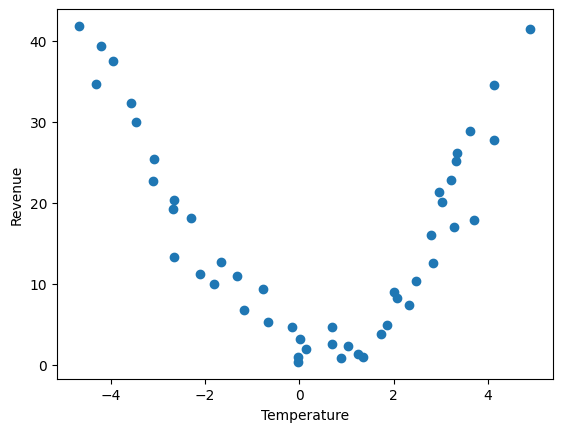

In [6]:
plt.scatter(x_train, y_train)
plt.xlabel("Temperature")
plt.ylabel("Revenue")
plt.show()

In [18]:
x_mean = np.mean(x_train)
x_std = np.std(x_train)
x_norm = (x_train - x_mean) / x_std

In [19]:
X_train = []
for i in range(len(x_norm)):
    row = [x_norm[i], x_norm[i]**2, x_norm[i]**3]
    X_train.append(row)

X_train = np.array(X_train)

In [20]:
def cost_function(X, y, w, b):
    m = len(X)
    cost_sum = 0
    for i in range(m):
        f = np.dot(w, X[i]) + b
        cost = (f - y[i]) ** 2
        cost_sum += cost
    return (1/(2*m)) * cost_sum

In [21]:
def gradient_function(X, y, w, b):
    m = len(X)
    dc_dw = np.zeros(w.shape)
    dc_db = 0
    for i in range(m):
        f = np.dot(w, X[i]) + b
        dc_dw += (f - y[i]) * X[i]
        dc_db += (f - y[i])
    dc_dw = (1/m) * dc_dw
    dc_db = (1/m) * dc_db
    return dc_dw, dc_db

In [22]:
def gradient_descent(X, y, alpha, iterations):
    w = np.zeros(X.shape[1])
    b = 0
    for i in range(iterations):
        dc_dw, dc_db = gradient_function(X, y, w, b)
        w = w - alpha * dc_dw
        b = b - alpha * dc_db
        if i % 500 == 0:
            print(f"Iteration {i}: Cost {cost_function(X, y, w, b)}")
    return w, b

In [23]:
learning_rate = 0.01
iterations = 10000

final_w, final_b = gradient_descent(X_train, y_train, learning_rate, iterations)
print(f"w: {final_w}, b: {final_b:.4f}")

Iteration 0: Cost 189.90585536083614
Iteration 500: Cost 4.986515742528783
Iteration 1000: Cost 4.7036062189382095
Iteration 1500: Cost 4.671200024627911
Iteration 2000: Cost 4.6652688894279155
Iteration 2500: Cost 4.663990795954766
Iteration 3000: Cost 4.663704924951617
Iteration 3500: Cost 4.663640501957326
Iteration 4000: Cost 4.6636259623633265
Iteration 4500: Cost 4.66362267998437
Iteration 5000: Cost 4.663621938930887
Iteration 5500: Cost 4.6636217716234905
Iteration 6000: Cost 4.6636217338504755
Iteration 6500: Cost 4.663621725322452
Iteration 7000: Cost 4.663621723397078
Iteration 7500: Cost 4.663621722962389
Iteration 8000: Cost 4.663621722864248
Iteration 8500: Cost 4.663621722842089
Iteration 9000: Cost 4.663621722837087
Iteration 9500: Cost 4.663621722835958
w: [-1.27620529 13.30417078  0.97860072], b: 2.7947
